# Aim :To build a deep learning model using an autoencoder on the MNIST dataset for removing noise from images and reconstructing clean images.


In [2]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 780.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 84.6 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

# Load MNIST dataset
(train_data, _), (test_data, _) = datasets.mnist.load_data()

# Assign to original variable names
x_train = train_data
x_test = test_data

# Example model structure (same concept)
model = Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.UpSampling2D(size=(2, 2))
])

print(x_train.shape)
print(x_test.shape)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


# 2 Normalize + Reshape

In [4]:
# Normalize pixel values
x_train = np.array(x_train, dtype=np.float32) / 255
x_test = np.array(x_test, dtype=np.float32) / 255

# Reshape images
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print(x_train.shape)

(60000, 28, 28, 1)


# 3 Add Noise

In [5]:
noise = 0.3

# Add Gaussian noise
train_noise = np.random.randn(*x_train.shape)
test_noise = np.random.randn(*x_test.shape)

x_train_noisy = np.clip(x_train + noise * train_noise, 0, 1)
x_test_noisy = np.clip(x_test + noise * test_noise, 0, 1)

# 4 Build Autoencoder

In [9]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

In [11]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

# 5 Compile

In [13]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# 6 Train

In [14]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 100ms/step - loss: 0.1469 - val_loss: 0.0960
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 98ms/step - loss: 0.0931 - val_loss: 0.0890
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 99ms/step - loss: 0.0884 - val_loss: 0.0862
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 98ms/step - loss: 0.0862 - val_loss: 0.0847
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 99ms/step - loss: 0.0848 - val_loss: 0.0836
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 99ms/step - loss: 0.0838 - val_loss: 0.0827
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 98ms/step - loss: 0.0830 - val_loss: 0.0820
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 98ms/step - loss: 0.0823 - val_loss: 0.0814
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 98ms/step - loss: 0.0818 - val_loss: 0.0810
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 98ms/step - loss: 0.0814 - val_loss: 0.0807


# 7 Predict

In [15]:
decoded_imgs = autoencoder.predict(x_test_noisy)
print(decoded_imgs.min(), decoded_imgs.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
1.5418769e-12 0.99931866


# 8 Visualization

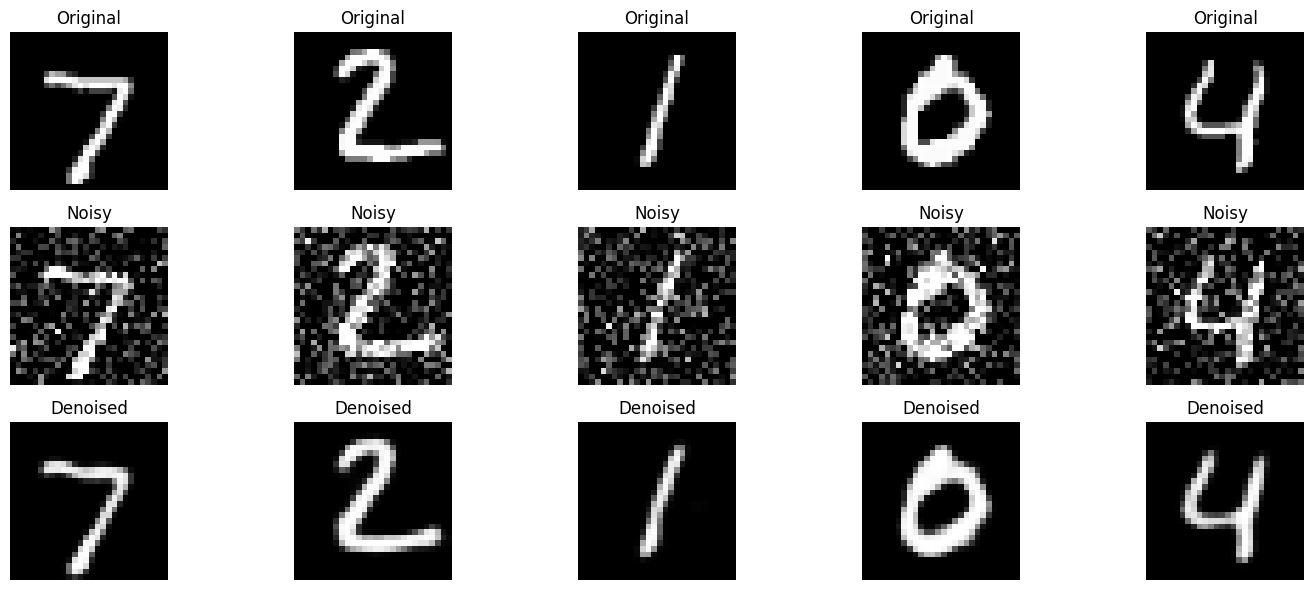

In [16]:
n = 5
plt.figure(figsize=(15, 6))

for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title("Original")

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title("Noisy")

    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title("Denoised")

plt.tight_layout()
plt.show()

# 9 Plot Training Loss

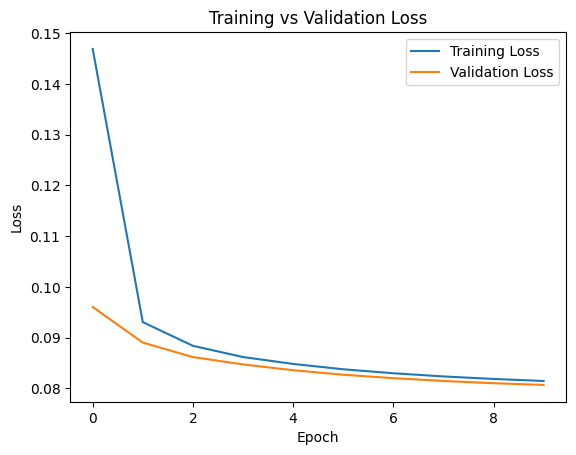

In [17]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.show()

# 🖼️ Image Denoising Using Autoencoder on MNIST

## 📌 Project Overview

This project demonstrates the implementation of a **Convolutional Autoencoder** using **TensorFlow/Keras** to remove **Gaussian noise** from handwritten digit images in the **MNIST dataset**.

The model is trained using **noisy images as input** and **clean images as target output**, enabling it to reconstruct denoised images effectively while preserving important handwritten digit features.

---

## 🎯 Objective

Build and train a deep learning autoencoder capable of reconstructing clean handwritten digit images from noisy inputs using the MNIST dataset.

---

## 📚 Dataset

**Dataset:** MNIST

* Training Images: **60,000**
* Testing Images: **10,000**
* Image Size: **28 × 28 pixels**
* Channels: **Grayscale (1 Channel)**

---

## 🛠️ Libraries Used

* TensorFlow / Keras
* NumPy
* Matplotlib

---

## ⚙️ Training Configuration

| Parameter     | Value               |
| ------------- | ------------------- |
| Optimizer     | Adam                |
| Loss Function | Binary Crossentropy |
| Epochs        | 10                  |
| Batch Size    | 128                 |
| Noise Type    | Gaussian Noise      |
| Noise Factor  | 0.3                 |

---

## 🔄 Methodology

### 1. Data Preprocessing

* Load the MNIST dataset
* Normalize image pixel values to the range **[0,1]**
* Reshape images into **28×28×1**

### 2. Noise Injection

* Apply **Gaussian noise** to training and testing images
* Clip pixel values to maintain valid image intensity ranges

### 3. Build Convolutional Autoencoder

#### Encoder

* Conv2D (32 filters)
* MaxPooling2D
* Conv2D (16 filters)
* MaxPooling2D

#### Decoder

* Conv2D (16 filters)
* UpSampling2D
* Conv2D (32 filters)
* UpSampling2D
* Final Conv2D with Sigmoid activation

### 4. Model Training

Train the autoencoder using:

* Input → Noisy Images
* Target → Clean Images

### 5. Image Reconstruction

Generate denoised outputs and compare them with original images.

---

## 📊 Results

### Model Performance

* Successfully reconstructed clean images from noisy inputs
* Training loss reduced from approximately **0.1504 → 0.0819**
* Validation loss reduced from approximately **0.0969 → 0.0810**
* Reconstructed images preserved handwritten digit structures while reducing noise

---

## 📈 Output

The notebook displays:

✅ Original Images
✅ Noisy Images
✅ Denoised Images
✅ Training Loss Curve
✅ Validation Loss Curve

---

##
